# 4.2. 색을 내는 분자

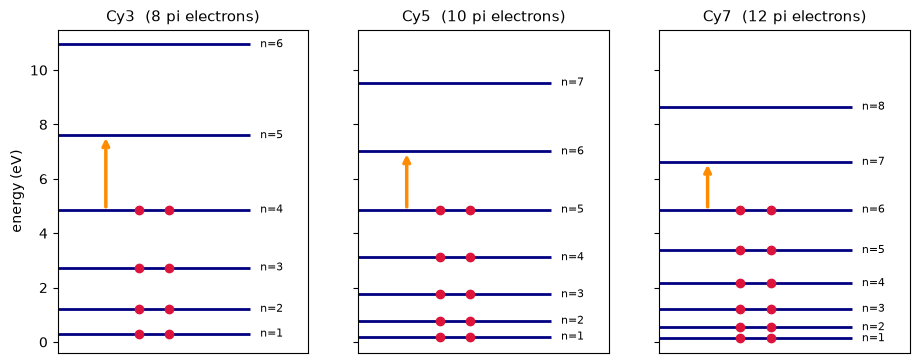

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import h, m_e, c, e

l = 139e-12
name = {1: "Cy3", 2: "Cy5", 3: "Cy7"}

fig, axes = plt.subplots(1, 3, figsize=(11, 4.2), sharey=True)

for ax, k in zip(axes, [1, 2, 3]):
    p = 2 * k + 3  # 사슬 탄소 수
    N = p + 3  # pi 전자 수
    L = (p + 3) * l  # 사슬 원자 수(p+2) + 1
    E0 = h**2 / (8 * m_e * L**2) / e  # n=1 에너지 (eV)
    homo = N // 2

    for n in range(1, homo + 3):
        E = n**2 * E0
        ax.hlines(E, 0, 1, lw=2, color="navy")
        if n <= homo:  # 채워진 준위
            ax.plot([0.42, 0.58], [E, E], "o", color="crimson", ms=6)
        ax.text(1.05, E, f"n={n}", va="center", fontsize=8)

    ax.annotate(
        "",
        xy=(0.25, (homo + 1) ** 2 * E0),
        xytext=(0.25, homo**2 * E0),
        arrowprops=dict(arrowstyle="->", color="darkorange", lw=2.5),
    )
    ax.set_xlim(0, 1.3)
    ax.set_xticks([])
    ax.set_title(f"{name[k]}  ({N} pi electrons)", fontsize=11)

axes[0].set_ylabel("energy (eV)")
plt.show()

In [2]:
def cyanine(k):
    p = 2 * k + 3  # 사슬 탄소 수
    N = p + 3  # pi 전자 수
    L = (p + 3) * l  # 상자 길이 = (원자 수 + 1) x 139 pm
    dE = (N + 1) * h**2 / (8 * m_e * L**2)
    return p, N, L, h * c / dE * 1e9  # 파장 (nm)


obs = {1: 544, 2: 638, 3: 742}

print(f"{'':>2} {'탄소':>4} {'pi':>4} {'L(pm)':>7} {'예측':>6} {'실측':>6} {'오차':>7}")
for k in [1, 2, 3]:
    p, N, L, lam = cyanine(k)
    o = obs[k]
    print(
        f"{name[k]:>3} {p:4d} {N:4d} {L*1e12:7.0f} {lam:8.2f} {o:7.1f} {(lam-o)/o*100:+7.1f}%"
    )

     탄소   pi   L(pm)     예측     실측      오차
Cy3    5    8    1112   453.01   544.0   -16.7%
Cy5    7   10    1390   579.14   638.0    -9.2%
Cy7    9   12    1668   705.65   742.0    -4.9%


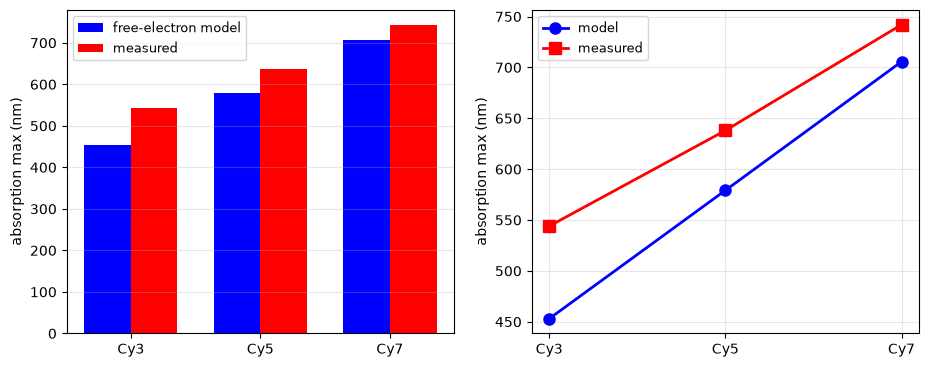

In [3]:
ks = [1, 2, 3]
pred = [cyanine(k)[3] for k in ks]
meas = [obs[k] for k in ks]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
xpos = np.arange(3)

a1.bar(xpos - 0.18, pred, 0.36, color="blue", label="free-electron model")
a1.bar(xpos + 0.18, meas, 0.36, color="red", label="measured")
a1.set_xticks(xpos)
a1.set_xticklabels([name[k] for k in ks])
a1.set_ylabel("absorption max (nm)")
a1.legend(fontsize=9)
a1.grid(alpha=0.3, axis="y")

a2.plot(ks, pred, "o-", color="blue", lw=2, ms=8, label="model")
a2.plot(ks, meas, "s-", color="red", lw=2, ms=8, label="measured")
a2.set_xticks(ks)
a2.set_xticklabels([name[k] for k in ks])
a2.set_ylabel("absorption max (nm)")
a2.legend(fontsize=9)
a2.grid(alpha=0.3)

plt.show()